# PIZZA SALES ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

### IMPORT DATASET

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/tymepas/Python-Data-Cleaning-and-Visualization/refs/heads/main/pizza_sales.csv")

### Metadata of Raw Data

In [4]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [5]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [6]:
# Rows and columns
print("The Metadata of the dataset: \n Rows", df.shape[0], "\n Columns:", df.shape[1])

The Metadata of the dataset: 
 Rows 48620 
 Columns: 12


In [7]:
# Columns names
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


### Data types in Raw Data

In [9]:
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [10]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


### KPI's

In [11]:
# Total Revenue
total_revenue = df['total_price'].sum()
# Total Pizza sold
total_pizza = df['quantity'].sum()
# Total Orders
total_orders = df['order_id'].nunique()
# Average Order Value
aov = total_revenue/total_orders
# Average Pizza per order
avg_order = total_pizza/total_orders


print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Pizza Sold: {total_pizza:,}")
print(f"Total Order: {total_orders:,}")
print(f"Average Order Value (AOV): ${aov:,.2f}")
print(f"Average Pizza per Order: {avg_order:.2f}")

Total Revenue: $817,860.05
Total Pizza Sold: 49,574
Total Order: 21,350
Average Order Value (AOV): $38.31
Average Pizza per Order: 2.32


### Chart's

#### Ingredient Analysis

In [12]:
ingredient = (
    df['pizza_ingredients']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'index':'Counts', 'pizza_ingredients': 'Indegredients'})
    
)

print(ingredient.head(10))

       Indegredients  count
0             Garlic  27422
1           Tomatoes  26601
2         Red Onions  19547
3        Red Peppers  16284
4  Mozzarella Cheese  10333
5          Pepperoni  10300
6            Spinach  10012
7          Mushrooms   9624
8            Chicken   8443
9          Capocollo   6572


#### Daily Trends - Total Orders

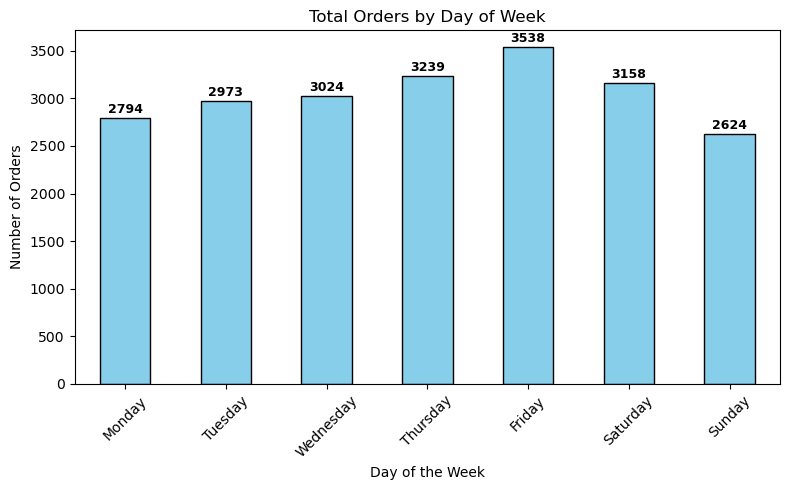

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['day_name'] = df['order_date'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

orders_by_day = df.groupby('day_name', observed=False)['order_id'].nunique()

ax = orders_by_day.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(8,5))

plt.title('Total Orders by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_day):
    plt.text(i, val+20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()




#### Daily Trends - Total Revenue

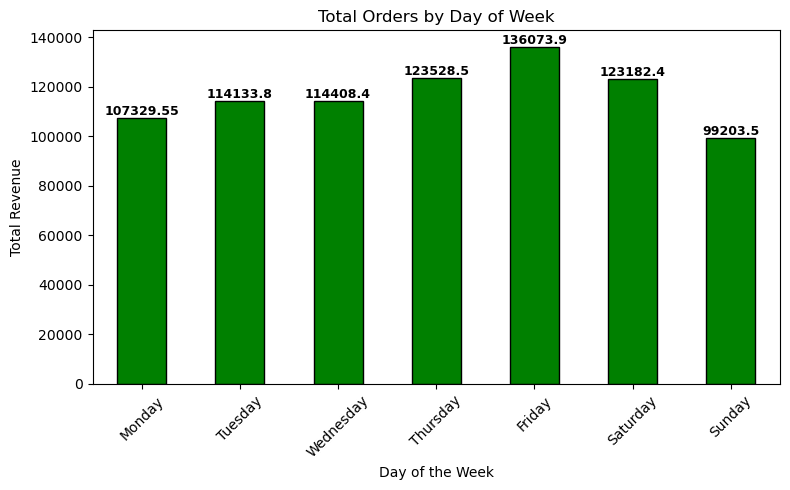

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['day_name'] = df['order_date'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

orders_by_day = df.groupby('day_name', observed=False)['total_price'].sum()

ax = orders_by_day.plot(kind='bar', color='green', edgecolor='black', figsize=(8,5))

plt.title('Total Orders by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_day):
    plt.text(i, val+20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()




#### Daily Trends - Total Quantity

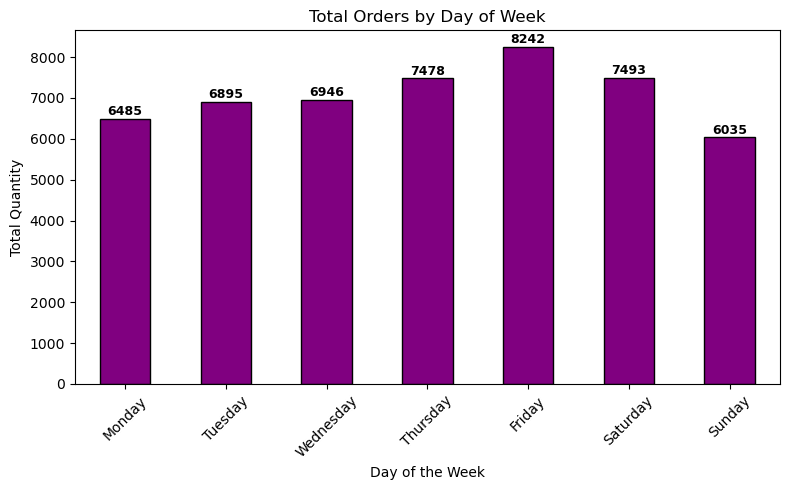

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['day_name'] = df['order_date'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

orders_by_day = df.groupby('day_name', observed=False)['quantity'].sum()

ax = orders_by_day.plot(kind='bar', color='purple', edgecolor='black', figsize=(8,5))

plt.title('Total Orders by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_day):
    plt.text(i, val+20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()


#### Hourly Trend - Total Orders

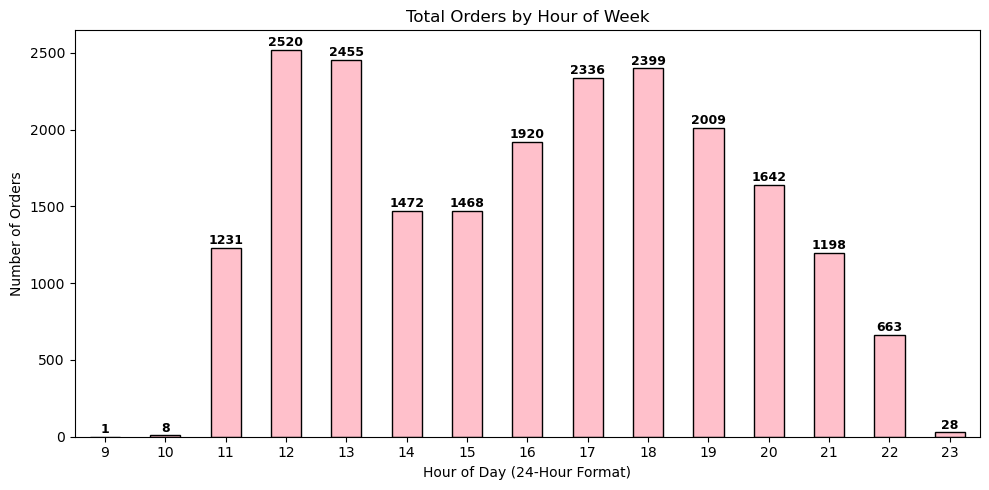

In [43]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

df['order_hour'] = df['order_time'].dt.hour

order_by_hour = df.groupby('order_hour', observed=False)['order_id'].nunique()

ax = order_by_hour.plot(kind='bar', color='pink', edgecolor='black', figsize=(10,5))

plt.title('Total Orders by Hour of Week')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

for i, val in enumerate(order_by_hour):
    plt.text(i, val+5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()

#### Hourly Trend - Total Revenue

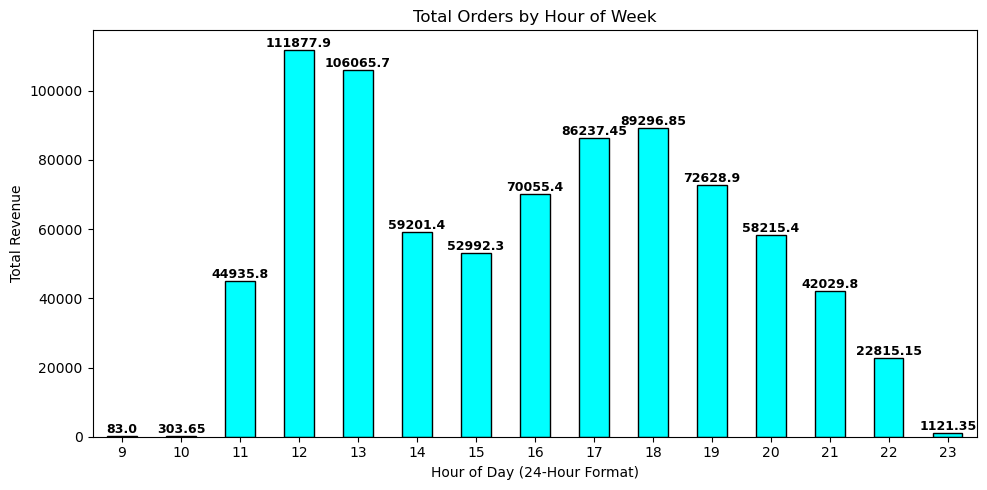

In [17]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

df['order_hour'] = df['order_time'].dt.hour

order_by_hour = df.groupby('order_hour', observed=False)['total_price'].sum()

ax = order_by_hour.plot(kind='bar', color='cyan', edgecolor='black', figsize=(10,5))

plt.title('Total Orders by Hour of Week')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

for i, val in enumerate(order_by_hour):
    plt.text(i, val+5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()

#### Hourly Trend - Total Quantity

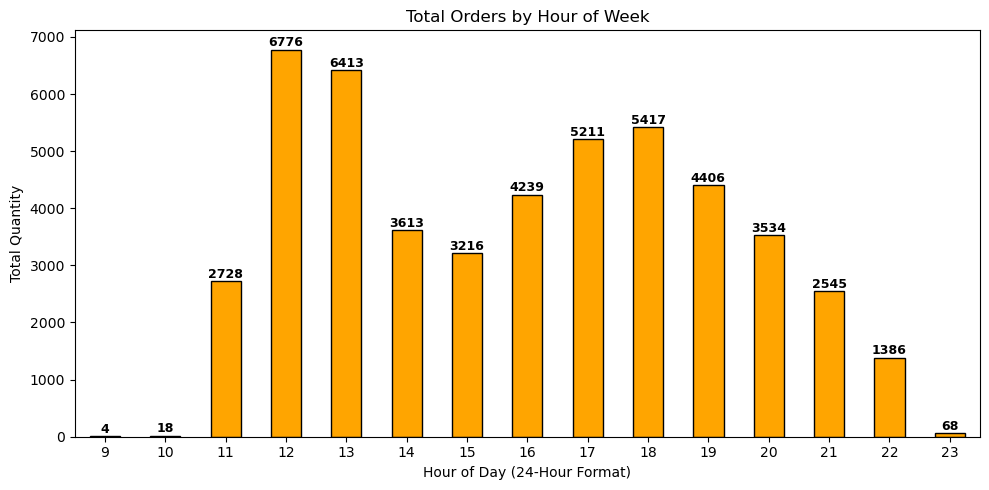

In [18]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

df['order_hour'] = df['order_time'].dt.hour

order_by_hour = df.groupby('order_hour', observed=False)['quantity'].sum()

ax = order_by_hour.plot(kind='bar', color='orange', edgecolor='black', figsize=(10,5))

plt.title('Total Orders by Hour of Week')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)

for i, val in enumerate(order_by_hour):
    plt.text(i, val+5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()

#### Monthly Trend - Total Orders

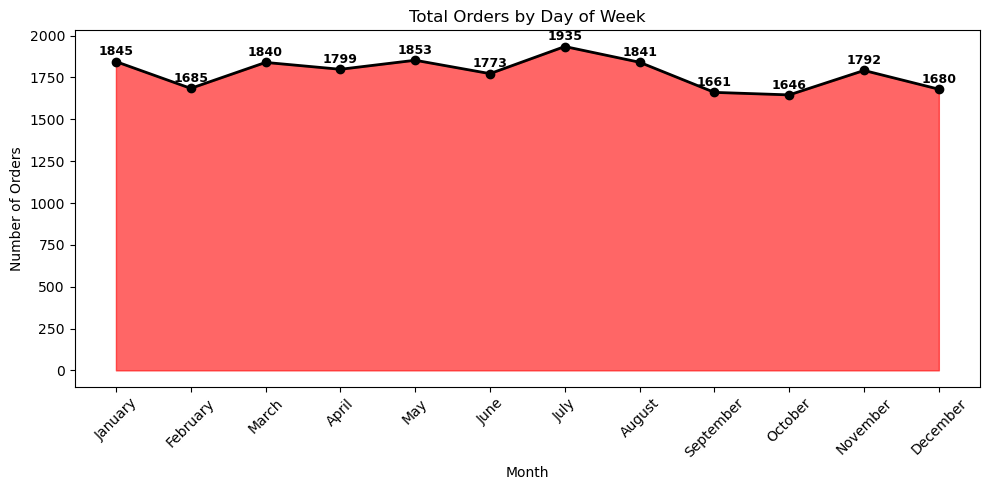

In [19]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['month_name'] = df['order_date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()

plt.figure(figsize=(10,5))
plt.fill_between(orders_by_month.index, orders_by_month.values, color='red', alpha=0.6)
plt.plot(orders_by_month.index, orders_by_month.values, color='black', linewidth=2, marker='o')

plt.title('Total Orders by Day of Week')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_month):
    plt.text(i, val+20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()

#### Monthly Trend - Total Revenue

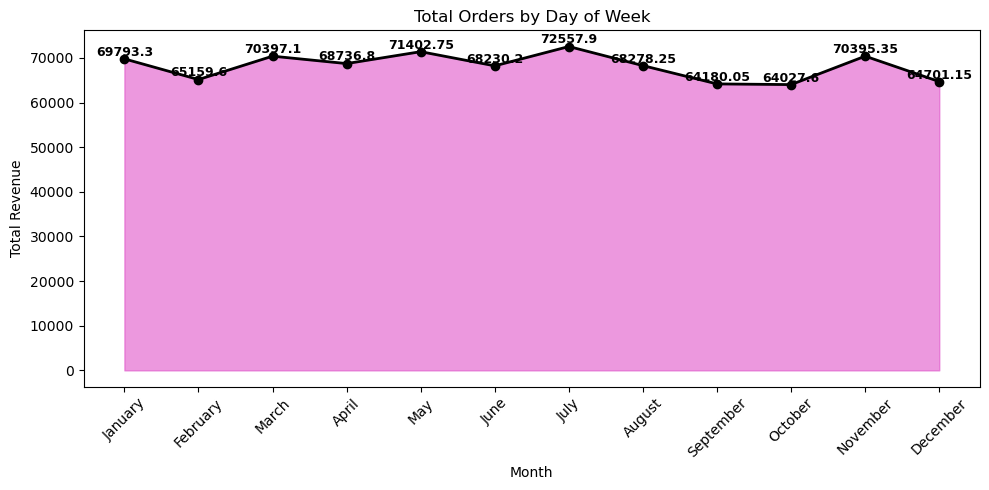

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['month_name'] = df['order_date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

orders_by_month = df.groupby('month_name', observed=False)['total_price'].sum()

plt.figure(figsize=(10,5))
plt.fill_between(orders_by_month.index, orders_by_month.values, color='#e053c9', alpha=0.6)
plt.plot(orders_by_month.index, orders_by_month.values, color='black', linewidth=2, marker='o')

plt.title('Total Orders by Day of Week')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_month):
    plt.text(i, val+20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()

#### Monthly Trend - Total Quantity

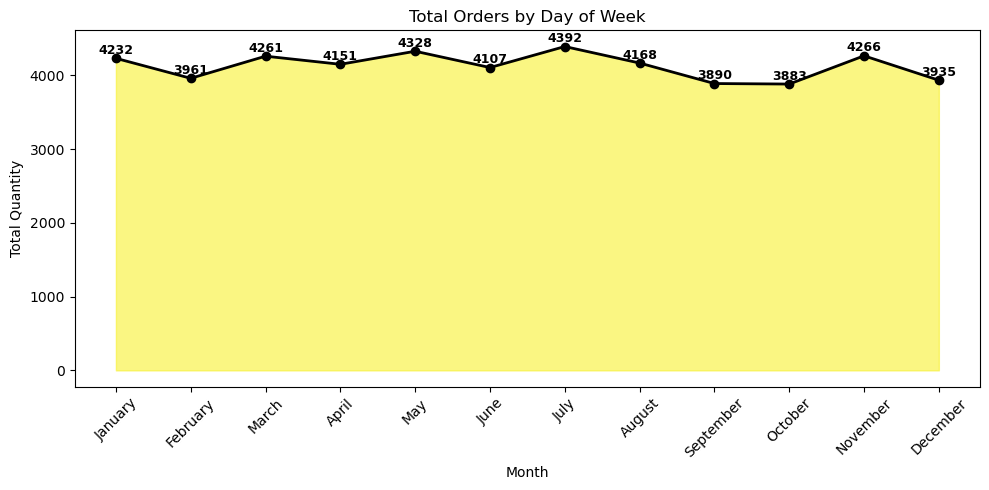

In [21]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['month_name'] = df['order_date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

orders_by_month = df.groupby('month_name', observed=False)['quantity'].sum()

plt.figure(figsize=(10,5))
plt.fill_between(orders_by_month.index, orders_by_month.values, color='#f7f12f', alpha=0.6)
plt.plot(orders_by_month.index, orders_by_month.values, color='black', linewidth=2, marker='o')

plt.title('Total Orders by Day of Week')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_month):
    plt.text(i, val+20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    
plt.tight_layout()
plt.show()

#### % of Sales by Category

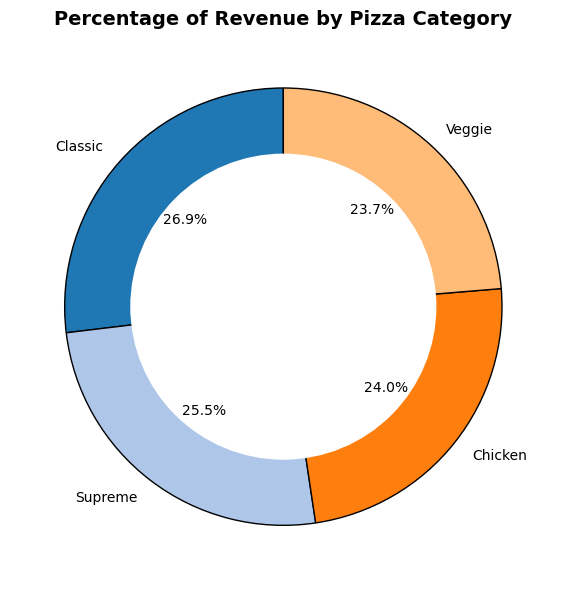

Top-selling category by revenue: Classic


In [22]:
category_sales = df.groupby('pizza_category')['total_price'].sum()
category_pct = category_sales / category_sales.sum()*100
category_pct = category_pct.sort_values(ascending=False)

plt.figure(figsize=(6,6))

colors = plt.get_cmap('tab20').colors #nice color palette

plt.pie(category_pct, labels=category_pct.index, 
        autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops={'edgecolor':'black', 'width':0.4},
        textprops={'fontsize': 10})

# Add center circle for donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Percentage of Revenue by Pizza Category", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top-selling category by revenue:", category_pct.idxmax())


#### % Sales by Pizza Size & Category

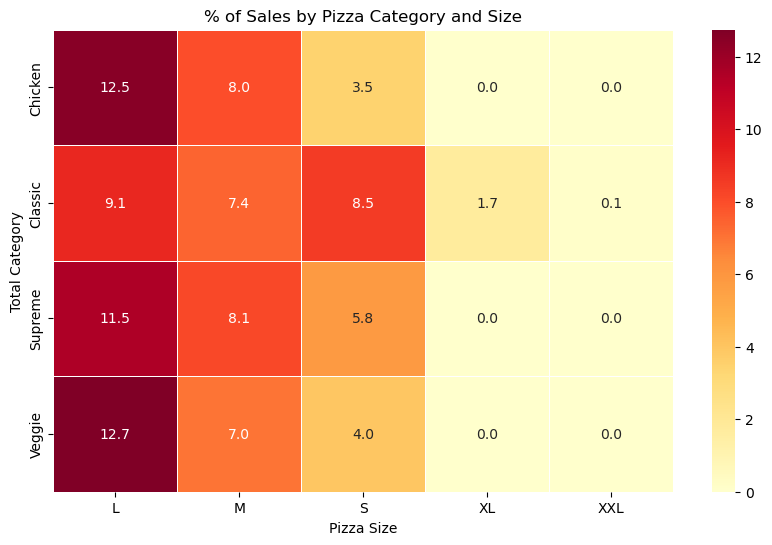

In [23]:
sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

sales_pct = sales_pivot / sales_pivot.sum().sum()*100

plt.figure(figsize=(10,6))
sns.heatmap(sales_pct, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title('% of Sales by Pizza Category and Size')
plt.xlabel('Pizza Size')
plt.ylabel('Total Category')
plt.show()

#### Total Pizzas Sold by Pizza Category

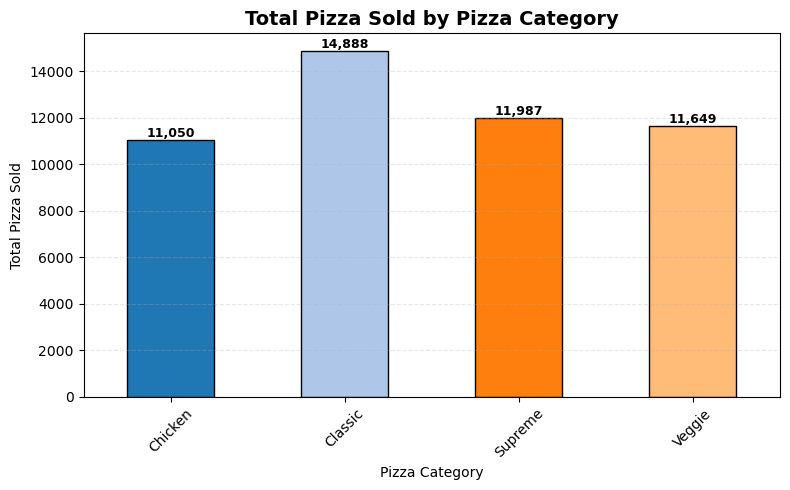

In [24]:
pizza_by_category = df.groupby('pizza_category')['quantity'].sum()
#pizza_by_category = pizza_by_category.sort_values(ascending=False)

colors = list(plt.get_cmap('tab20').colors)

colors = colors[:len(pizza_by_category)]

ax = pizza_by_category.plot(kind='bar', figsize=(8,5), color=colors, edgecolor='black')

plt.title("Total Pizza Sold by Pizza Category", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizza Sold")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, val in enumerate(pizza_by_category):
    plt.text(i, val+5, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Top 5 Best-Selling Pizzas - Total Quantity

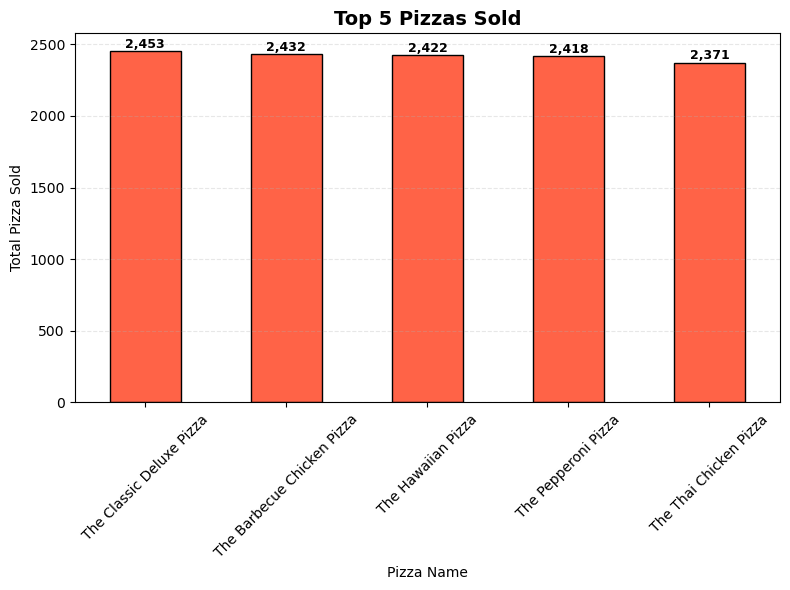

In [25]:
pizza_by_name = df.groupby('pizza_name')['quantity'].sum()

top5 = pizza_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,6), color='tomato', edgecolor='black')

plt.title("Top 5 Pizzas Sold", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizza Sold")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for i, val in enumerate(top5):
    plt.text(i, val+2, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Top 5 Best-Selling Pizzas - Total Orders

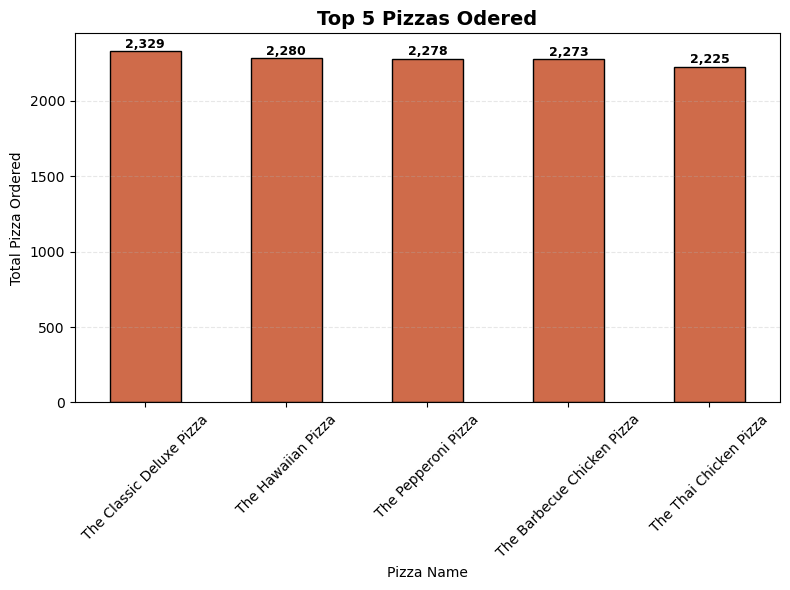

In [26]:
pizza_by_name = df.groupby('pizza_name')['order_id'].nunique()

top5 = pizza_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,6), color='#cf6b4a', edgecolor='black')

plt.title("Top 5 Pizzas Odered", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizza Ordered")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for i, val in enumerate(top5):
    plt.text(i, val+2, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Top 5 Best-Selling Pizzas - Total Sales

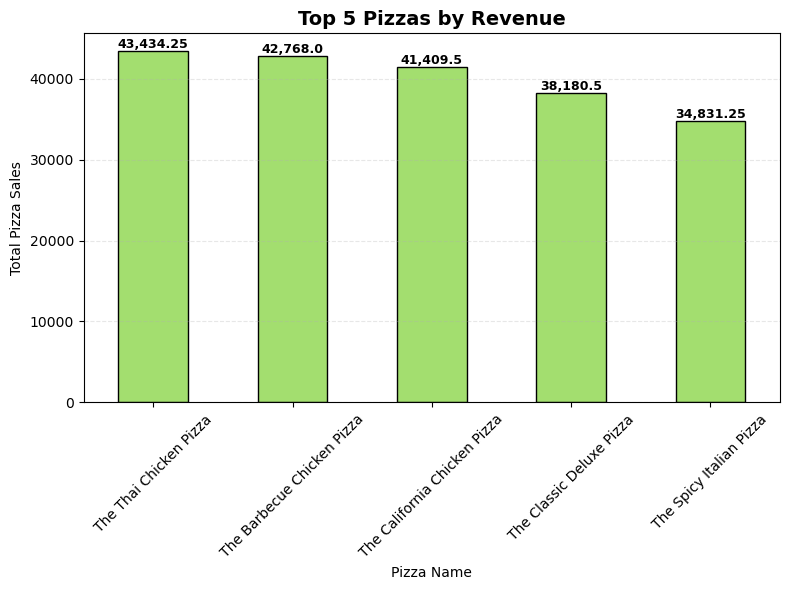

In [27]:
pizza_by_name = df.groupby('pizza_name')['total_price'].sum()

top5 = pizza_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,6), color='#a3de6f', edgecolor='black')

plt.title("Top 5 Pizzas by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizza Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for i, val in enumerate(top5):
    plt.text(i, val+2, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Bottom 5 Least-Selling Pizzas - Total Sales

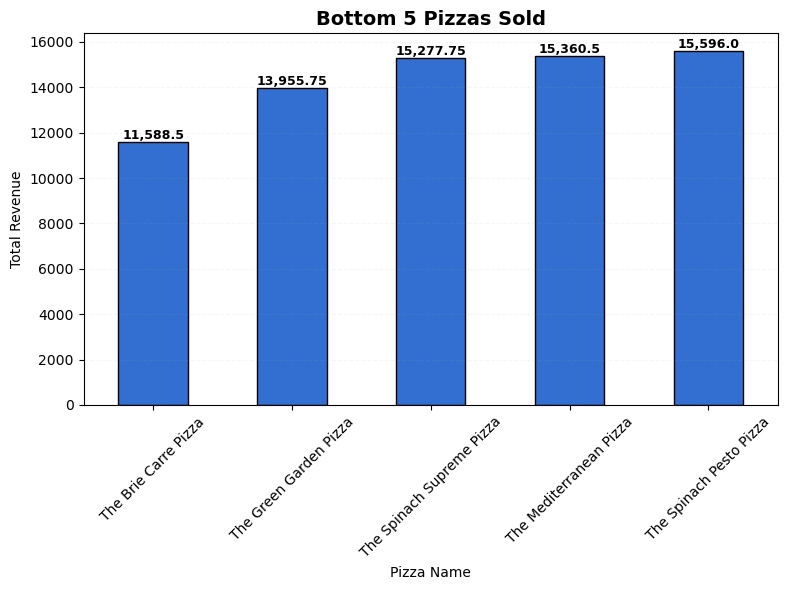

In [28]:
pizza_by_name = df.groupby('pizza_name')['total_price'].sum()

bottom5 = pizza_by_name.sort_values(ascending=True).head(5)

ax = bottom5.plot(kind='bar', figsize=(8,6), color='#326fd1', edgecolor='black')

plt.title("Bottom 5 Pizzas Sold", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.1)


for i, val in enumerate(bottom5):
    plt.text(i, val+2, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Bottom 5 Least-Selling Pizzas - Total Orders

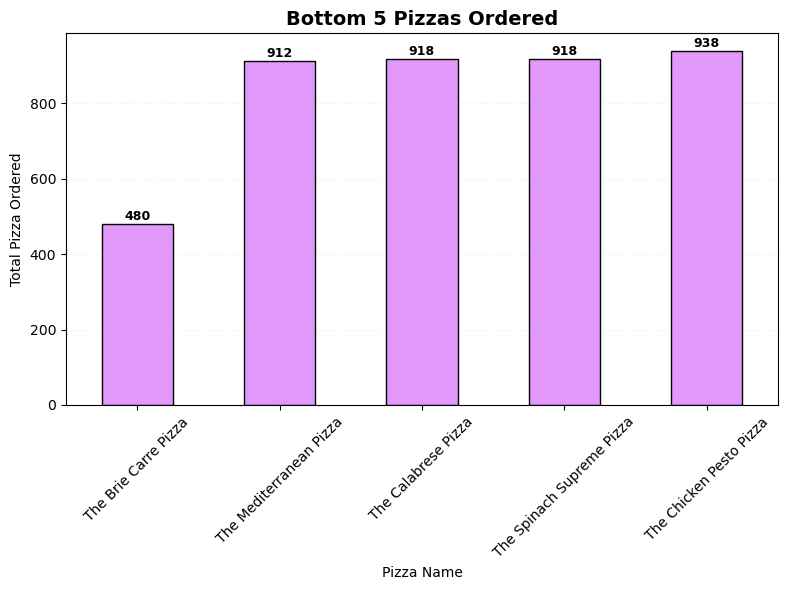

In [29]:
pizza_by_name = df.groupby('pizza_name')['order_id'].nunique()

bottom5 = pizza_by_name.sort_values(ascending=True).head(5)

ax = bottom5.plot(kind='bar', figsize=(8,6), color='#e298fa', edgecolor='black')

plt.title("Bottom 5 Pizzas Ordered", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizza Ordered")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.1)


for i, val in enumerate(bottom5):
    plt.text(i, val+2, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Bottom 5 Least-Selling Pizzas - Total Quantity

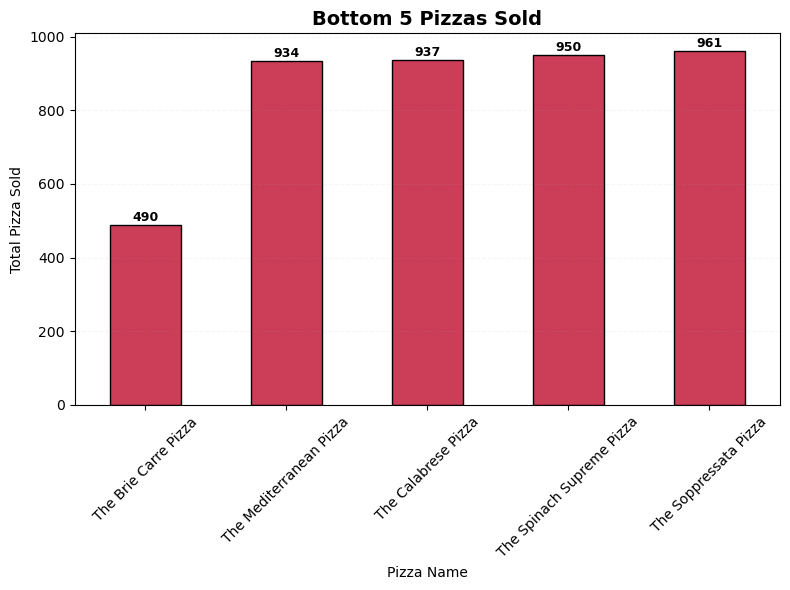

In [30]:
pizza_by_name = df.groupby('pizza_name')['quantity'].sum()

bottom5 = pizza_by_name.sort_values(ascending=True).head(5)

ax = bottom5.plot(kind='bar', figsize=(8,6), color='#cc3d57', edgecolor='black')

plt.title("Bottom 5 Pizzas Sold", fontsize=14, fontweight='bold')
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizza Sold")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.1)


for i, val in enumerate(bottom5):
    plt.text(i, val+2, f"{val:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Business Questions Answered

In [31]:
print("1. What is the total revenue generated?")

total_revenue = df['total_price'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

1. What is the total revenue generated?
Total Revenue: $817,860.05


In [32]:
print("2. How many pizzas were sold in total?")

pizza_sold = df['quantity'].sum()
print(f"The total pizza sold: {pizza_sold}")

2. How many pizzas were sold in total?
The total pizza sold: 49574


In [33]:
print("3. Which category and size of pizzas perform best?")

pizza_cat = df.groupby('pizza_category')['quantity'].sum().sort_values(ascending=False)
pizza_sz = df.groupby('pizza_size')['total_price'].sum().sort_values(ascending=False)

print(f"The best Pizza by Category: {pizza_cat.idxmax()} & by Size: {pizza_sz.idxmax()}")

3. Which category and size of pizzas perform best?
The best Pizza by Category: Classic & by Size: L


In [34]:
print("4. Which pizzas are the top and bottom performers?")


top5 = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(5)

bottom5 = df.groupby('pizza_name')['quantity'].sum().sort_values().head(5)

print(f"\nThe Top Performers Pizzas are:\n {top5}\n")
print(f"the Bottom Performers Pizzas are: \n {bottom5}")

4. Which pizzas are the top and bottom performers?

The Top Performers Pizzas are:
 pizza_name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

the Bottom Performers Pizzas are: 
 pizza_name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


In [35]:
print("5. What is the average order value and average pizzas per order?")

total_orders = df['order_id'].nunique()
aov = total_revenue / total_orders
avg_pizzas_per_order = pizza_sold / total_orders

print(f"Average Order Value: ${aov:,.2f}")
print(f"Avg Pizzas per Order: {avg_pizzas_per_order:.2f}")

5. What is the average order value and average pizzas per order?
Average Order Value: $38.31
Avg Pizzas per Order: 2.32


6. What are the sales trends by day, month, and time of day?


C:\Users\Meet Chaurasia\AppData\Local\Temp\ipykernel_2764\2185492481.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sales = df.groupby('day_name')['quantity'].sum()


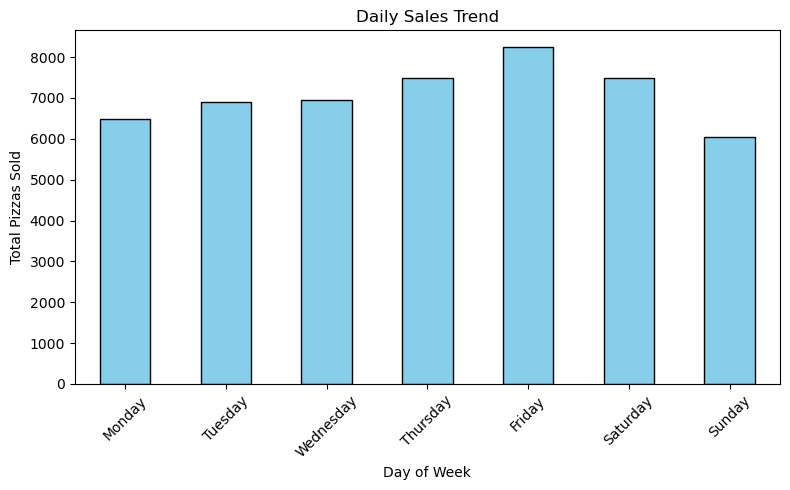

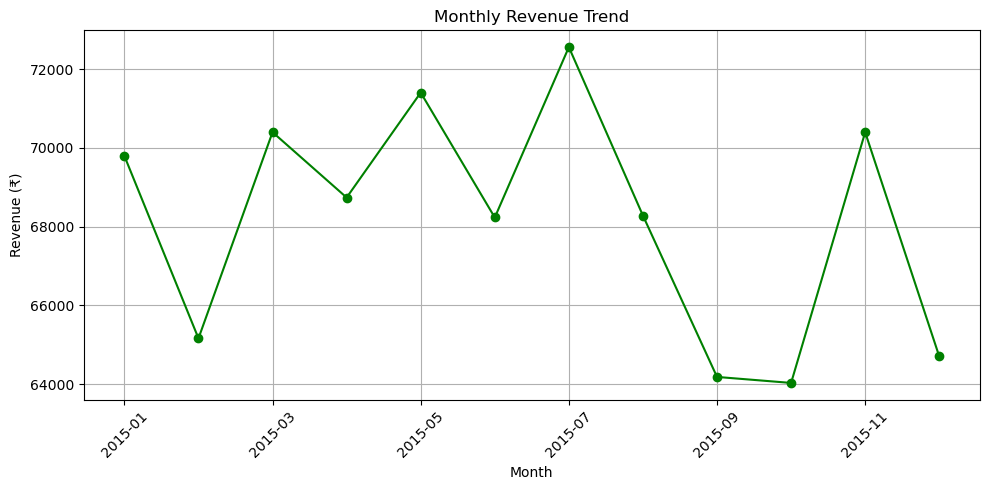

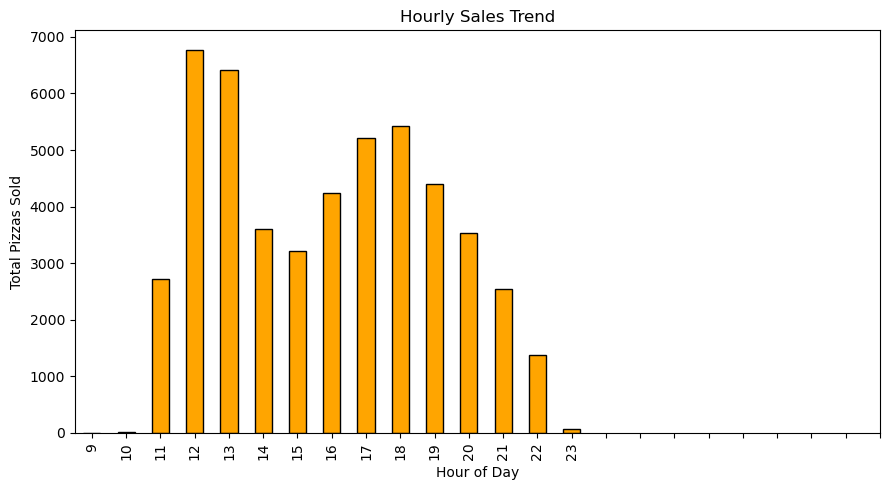

In [36]:
print("6. What are the sales trends by day, month, and time of day?")

# Convert order_date and order_time to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

# Extract day name, month, and hour
df['day_name'] = df['order_date'].dt.day_name()
df['month'] = df['order_date'].dt.to_period('M').astype(str)
df['hour'] = df['order_time'].dt.hour

# Set weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

# Grouped data
daily_sales = df.groupby('day_name')['quantity'].sum()
monthly_sales = df.groupby('month')['total_price'].sum()
hourly_sales = df.groupby('hour')['quantity'].sum()

# Plot: Daily Trend
plt.figure(figsize=(8,5))
daily_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Daily Sales Trend')
plt.xlabel('Day of Week')
plt.ylabel('Total Pizzas Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot: Monthly Trend
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot: Hourly Trend
plt.figure(figsize=(9,5))
hourly_sales.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Hourly Sales Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Total Pizzas Sold')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()